# Tokamak Plasma Video Data Visualization

This notebook visualizes tokamak video data with bounding box annotations.

## 1. Import Libraries

In [1]:
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from pathlib import Path
from IPython.display import HTML, Video
import torch

# Add ingestion_program to path
sys.path.insert(0, 'ingestion_program')
from tokam2d_utils import TokamDataset

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

Load the tokamak dataset with labeled bounding boxes.

In [2]:
!pwd

/home/nicolas/Desktop/Polytechnique/datacamp/codalab_tokam2d


In [3]:
# Specify your data directory
import gc
from pathlib import Path
data_dir = Path('./dev_phase/input_data/train')  # Adjust this path as needed

# Load dataset
dataset = TokamDataset(data_dir, include_unlabeled=True)
print(f"Total samples: {len(dataset)}")

# Count labeled samples (memory-efficient with cleanup)
labeled_indices = []
unlabeled_indices = []

for idx in range(len(dataset)):
    _, target = dataset[idx]
    if target['boxes'] is not None and len(target['boxes']) > 0:
        labeled_indices.append(idx)
    else:
        unlabeled_indices.append(idx)
    
    # Periodic cleanup every 100 samples
    if idx % 100 == 0:
        gc.collect()

print(f"Labeled samples: {len(labeled_indices)}")
print(f"Unlabeled samples: {len(unlabeled_indices)}")

# Clear memory
gc.collect()

Found annotations for 30 frames in 2 files.
Loaded 38 frames.
Total samples: 38
Labeled samples: 30
Unlabeled samples: 8


0

In [4]:
# Debug: Check what's in the target dictionary
if labeled_indices:
    sample_img, sample_target = dataset[labeled_indices[0]]
    print("Target keys:", sample_target.keys())
    print("\nTarget structure:")
    for key, value in sample_target.items():
        if value is not None:
            if hasattr(value, 'shape'):
                print(f"  {key}: shape={value.shape}, dtype={value.dtype}")
            elif hasattr(value, '__len__'):
                print(f"  {key}: length={len(value)}, type={type(value)}")
            else:
                print(f"  {key}: {value}")
        else:
            print(f"  {key}: None")
    
    # Show first box and label if available
    if sample_target['boxes'] is not None and len(sample_target['boxes']) > 0:
        print(f"\nFirst box: {sample_target['boxes'][0]}")
        if 'labels' in sample_target and sample_target['labels'] is not None:
            print(f"First label: {sample_target['labels'][0] if len(sample_target['labels']) > 0 else 'N/A'}")
    
    del sample_img, sample_target
    gc.collect()

Target keys: dict_keys(['boxes', 'labels', 'frame_index'])

Target structure:
  boxes: shape=torch.Size([1, 4]), dtype=torch.float32
  labels: shape=torch.Size([1]), dtype=torch.int64
  frame_index: length=9, type=<class 'str'>

First box: tensor([132.7600, 163.1900, 192.3200, 344.4200])
First label: 1


## 3. Visualize Single Frame with Labels

Display a single frame with its bounding box annotation.

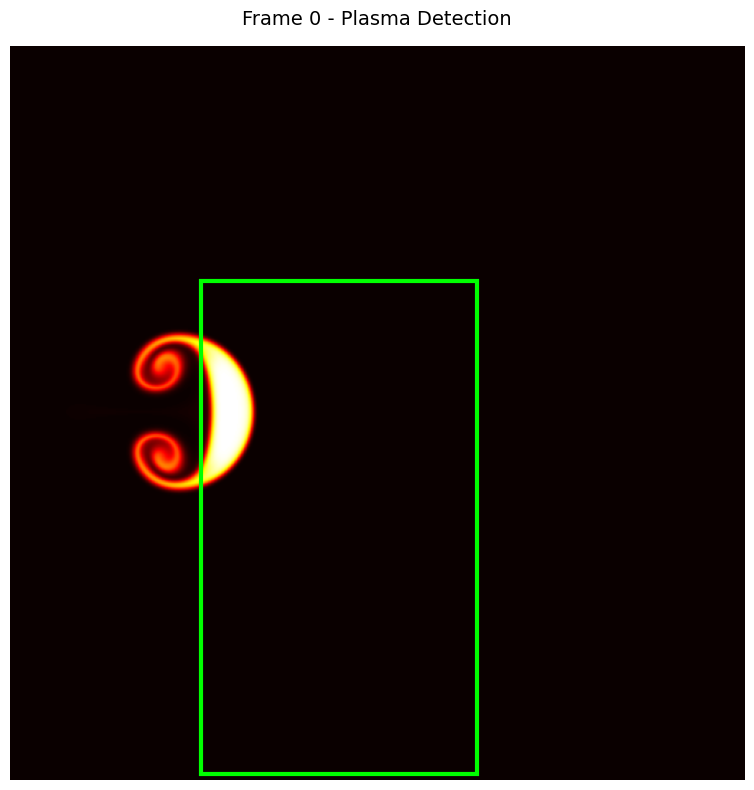

Image shape: (512, 512)
Number of boxes: 1
Memory cleared successfully


In [5]:
import gc

# Pick a labeled sample
sample_idx = labeled_indices[0] if labeled_indices else 0

# Load and immediately convert to numpy to reduce memory
image, target = dataset[sample_idx]
img_np = image.squeeze().cpu().numpy() if hasattr(image, 'cpu') else image.squeeze().numpy()

# Extract box data before creating plot
boxes_data = []
if target['boxes'] is not None and len(target['boxes']) > 0:
    for box in target['boxes']:
        box_np = box.cpu().numpy() if hasattr(box, 'cpu') else box.numpy()
        boxes_data.append(box_np)

# Clear tensors immediately
del image, target
gc.collect()

# Create smaller figure to save memory
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img_np, cmap='hot')
ax.axis('off')

# Draw bounding boxes from extracted data
count = 1
for box_data in boxes_data:
    x, y, w, h = boxes_data[0]
    x_pixel = x 
    y_pixel = y 
    w_pixel = w 
    h_pixel = h 

    rect = patches.Rectangle((x_pixel, y_pixel), w_pixel, h_pixel,
                            linewidth=3, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)

    # ax.text(x_pixel, y_pixel - 10, f'Plasma', 
    #         color='lime', fontsize=12, weight='bold',
    #         bbox=dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.7))
    # count-=1

    ax.set_title(f'Frame {sample_idx} - Plasma Detection', fontsize=14, pad=15)
    plt.tight_layout()

# Display and immediately close to prevent memory issues
plt.show()
plt.close(fig)

print(f"Image shape: {img_np.shape}")
print(f"Number of boxes: {len(boxes_data)}")

# Aggressive cleanup
del img_np, boxes_data, fig, ax
gc.collect()
print("Memory cleared successfully")

### Alternative: Ultra Low Memory Version

If you're still experiencing memory issues, use this simpler version that uses minimal memory.

In [6]:
import gc
from PIL import Image

# Ultra low memory approach - save directly to file without matplotlib
sample_idx = labeled_indices[0] if labeled_indices else 0
print(f"Processing frame {sample_idx}")

# Load frame
image, target = dataset[sample_idx]
img_np = image.squeeze().cpu().numpy() if hasattr(image, 'cpu') else image.squeeze().numpy()

# Extract box info
boxes_info = []
if target['boxes'] is not None and len(target['boxes']) > 0:
    for box in target['boxes']:
        box_np = box.cpu().numpy() if hasattr(box, 'cpu') else box.numpy()
        boxes_info.append(box_np)
    print(f"Found {len(boxes_info)} boxes")
else:
    print("No boxes found")

# Print box coordinates without plotting
for i, box in enumerate(boxes_info):
    x, y, w, h = box
    print(f"Box {i+1}: x={x:.3f}, y={y:.3f}, w={w:.3f}, h={h:.3f}")
    print(f"  -> Pixel coords: ({x*512:.0f}, {y*512:.0f}), size: ({w*512:.0f}, {h*512:.0f})")

print(f"\nImage shape: {img_np.shape}")

# Cleanup
del image, target, img_np, boxes_info
gc.collect()
print("Done - memory cleared")

Processing frame 0
Found 1 boxes
Box 1: x=132.760, y=163.190, w=192.320, h=344.420
  -> Pixel coords: (67973, 83553), size: (98468, 176343)

Image shape: (512, 512)
Done - memory cleared


## 4. Visualize Multiple Frames

Display a grid of frames from the dataset.

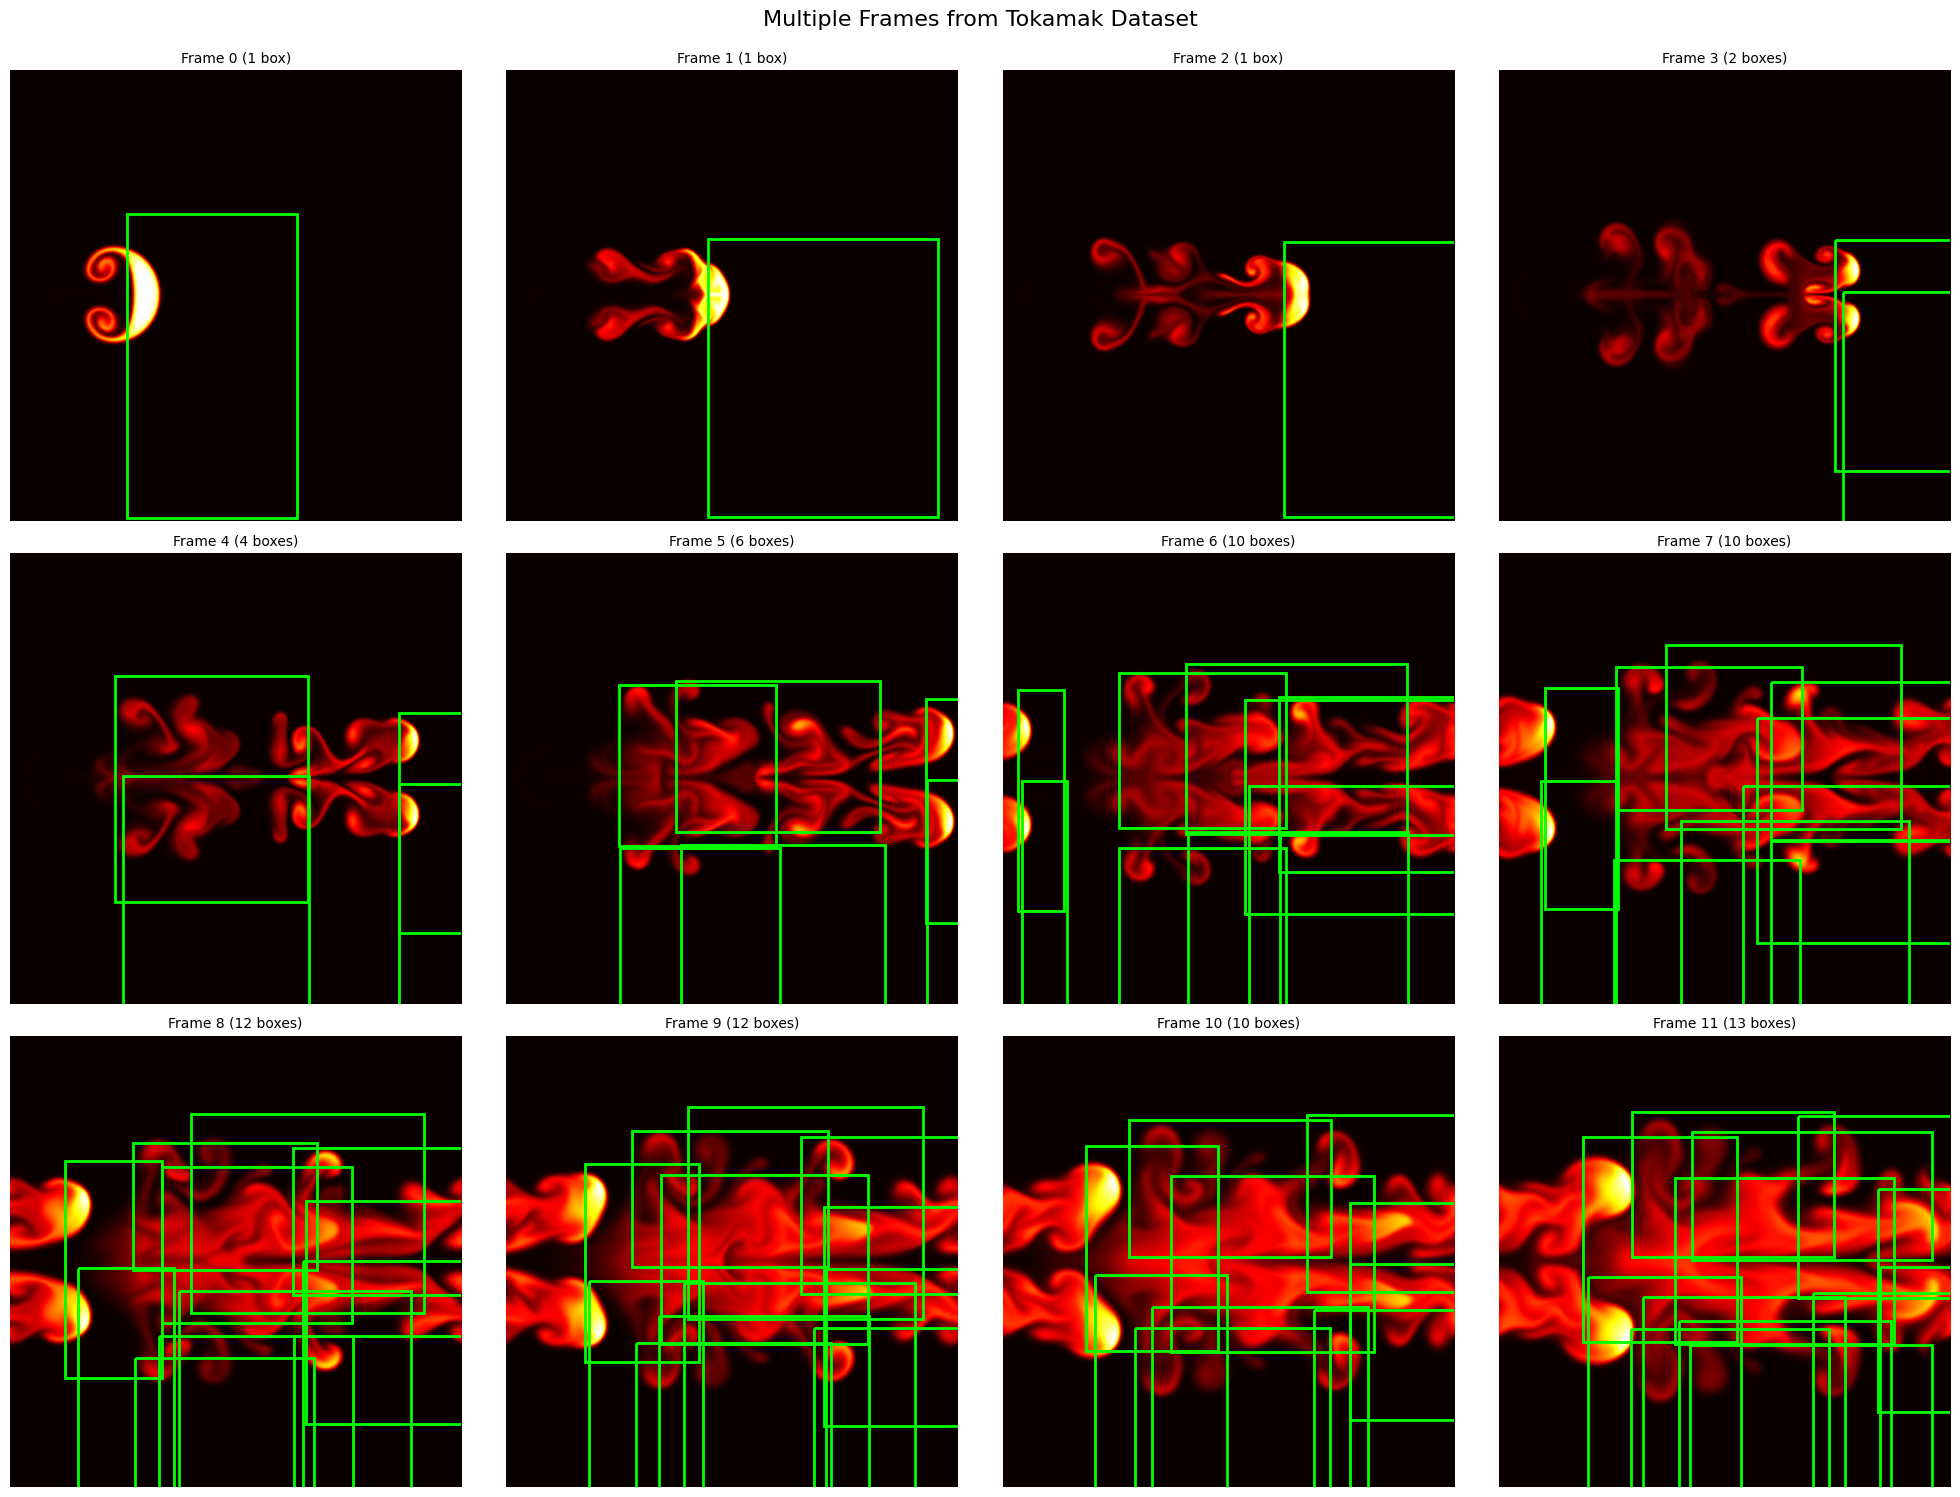

In [7]:
# Select frames to display (mix of labeled and unlabeled)
num_frames = 12
frame_indices = labeled_indices[:num_frames] if len(labeled_indices) >= num_frames else list(range(num_frames))

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for idx, frame_idx in enumerate(frame_indices):
    if frame_idx >= len(dataset):
        break
        
    image, target = dataset[frame_idx]
    img_np = image.squeeze().numpy()
    
    axes[idx].imshow(img_np, cmap='hot')
    axes[idx].axis('off')
    
    # Draw bounding boxes
    has_boxes = False
    if target['boxes'] is not None and len(target['boxes']) > 0:
        has_boxes = True
        for box in target['boxes']:
            x, y, w, h = box.numpy()
            x_pixel = x 
            y_pixel = y 
            w_pixel = w 
            h_pixel = h 
            
            rect = patches.Rectangle((x_pixel, y_pixel), w_pixel, h_pixel,
                                    linewidth=2, edgecolor='lime', facecolor='none')
            axes[idx].add_patch(rect)
    
    title = f'Frame {frame_idx}'
    if has_boxes:
        title += f' ({len(target["boxes"])} box{"es" if len(target["boxes"]) > 1 else ""})'
    else:
        title += ' (no labels)'
    axes[idx].set_title(title, fontsize=10)

plt.suptitle('Multiple Frames from Tokamak Dataset', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

## 5. Load Raw Video Data from HDF5

Load video sequences directly from HDF5 files to create animations.

In [8]:
# Find available HDF5 files
data_path = Path(data_dir)
h5_files = sorted(list(data_path.glob('*.h5')))

print(f"Found {len(h5_files)} HDF5 files:")
for f in h5_files:
    print(f"  - {f.name}")

# Load the first file to explore structure
if h5_files:
    sample_file = h5_files[0]
    print(f"\nExploring: {sample_file.name}")
    
    with h5py.File(sample_file, 'r') as f:
        print(f"\nKeys in file: {list(f.keys())}")
        
        # Try common keys
        for key in ['rho', 'images', 'data']:
            if key in f:
                data = f[key]
                print(f"\n'{key}' dataset:")
                print(f"  Shape: {data.shape}")
                print(f"  Dtype: {data.dtype}")
                print(f"  Number of frames: {data.shape[0]}")
                break
        else:
            # Use first key if standard ones not found
            key = list(f.keys())[0]
            data = f[key]
            print(f"\nUsing first key '{key}':")
            print(f"  Shape: {data.shape}")
            print(f"  Dtype: {data.dtype}")

Found 3 HDF5 files:
  - blob_dwi.h5
  - blob_i.h5
  - turb_i.h5

Exploring: blob_dwi.h5

Keys in file: ['density', 'indices']

Using first key 'density':
  Shape: (10, 512, 512)
  Dtype: float64


## 6. Visualize Video Sequence

Display a sequence of consecutive frames from a video.

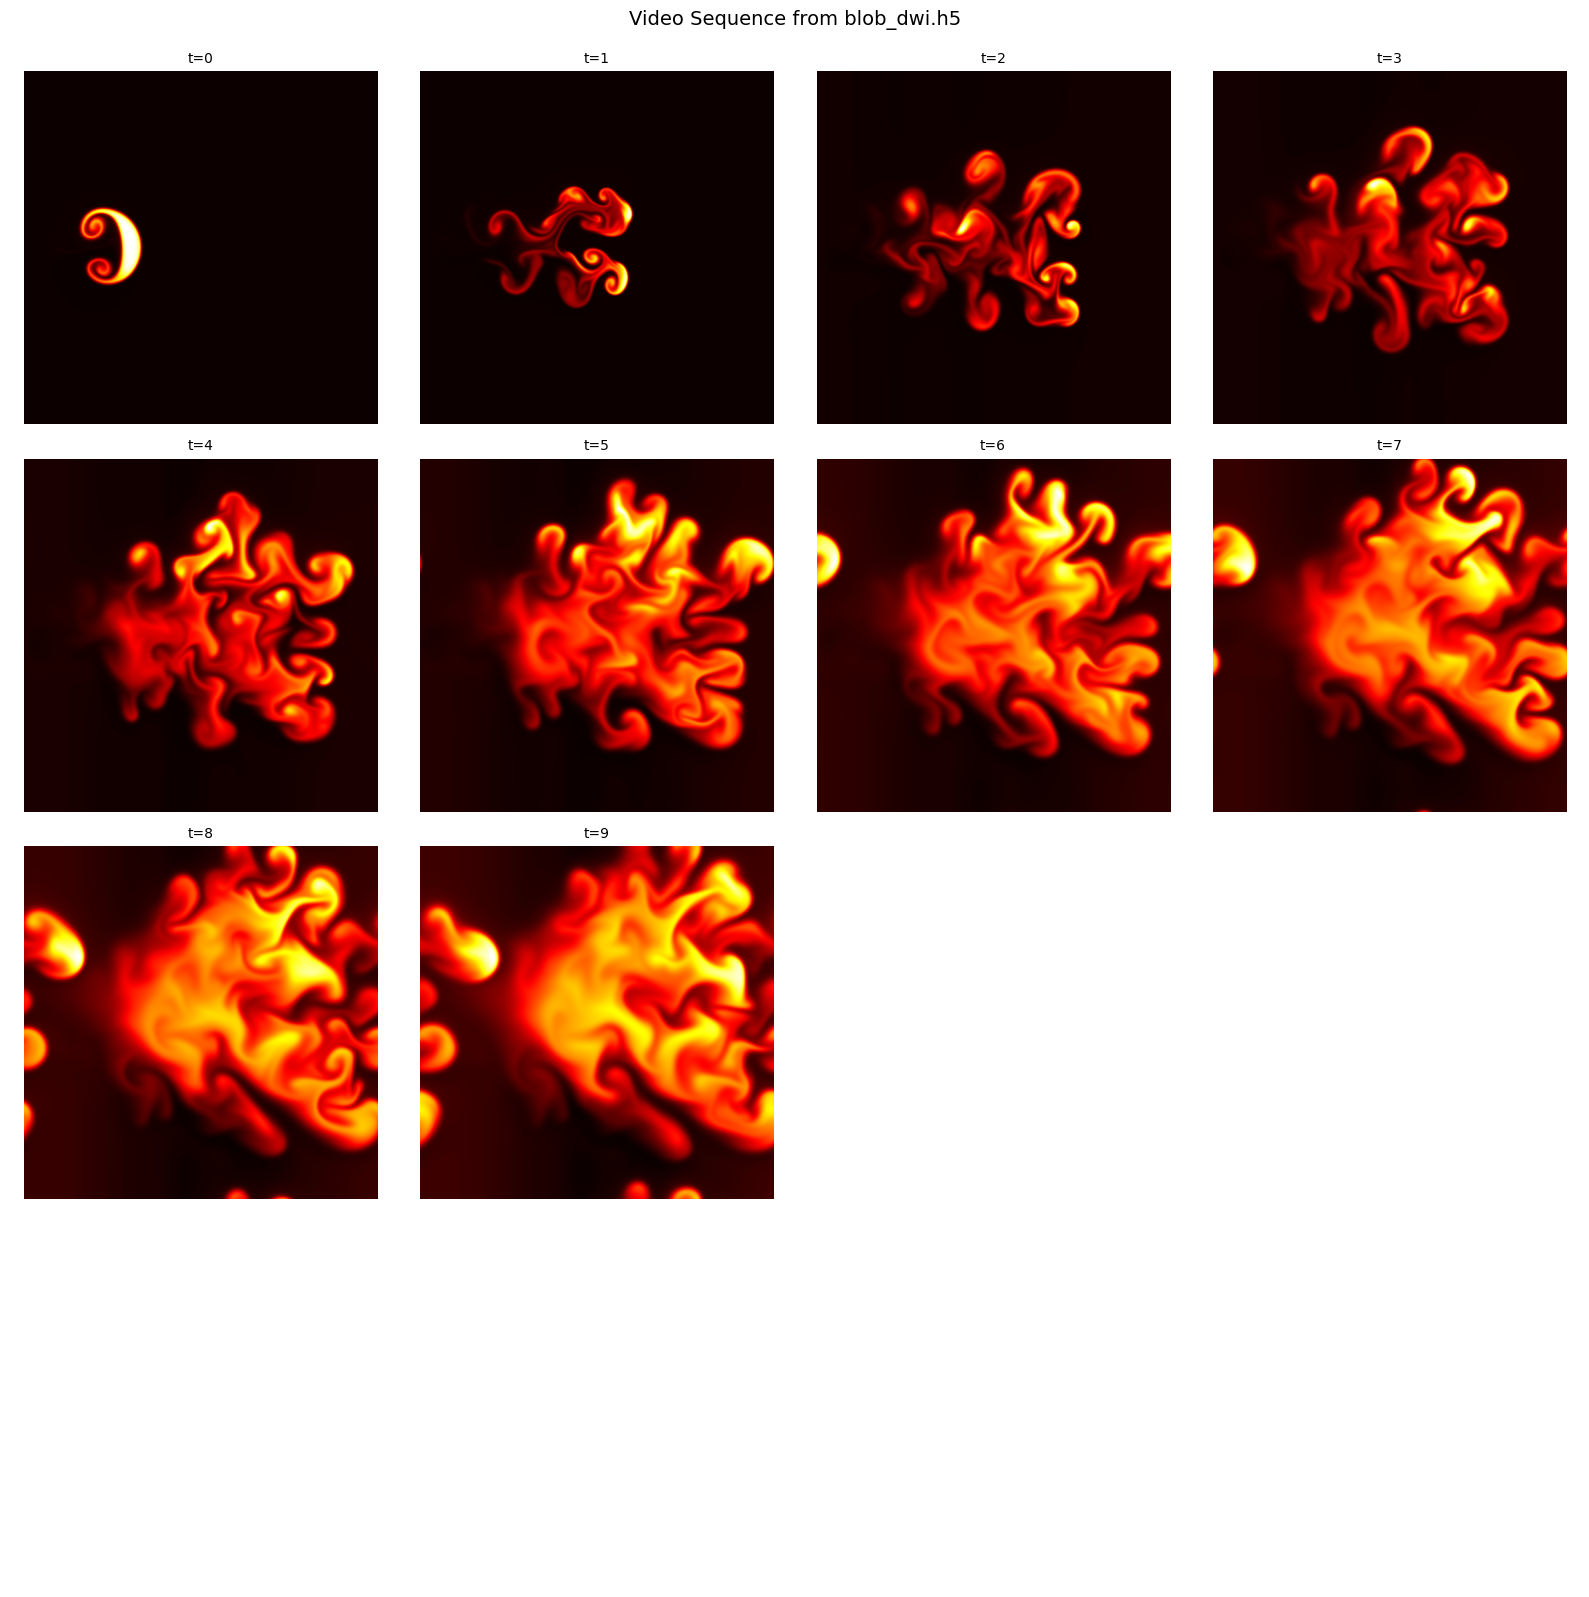

Video shape: (10, 512, 512)
Frame range: 0.9782 to 4.9863


In [9]:
# Load video frames (memory-efficient approach)
if h5_files:
    with h5py.File(h5_files[0], 'r') as f:
        # Auto-detect key
        key = None
        for possible_key in ['rho', 'images', 'data']:
            if possible_key in f:
                key = possible_key
                break
        if key is None:
            key = list(f.keys())[0]
        
        video_dataset = f[key]
        video_shape = video_dataset.shape
        
        # Select frames to display (evenly spaced)
        num_frames = min(16, video_shape[0])
        frame_step = max(1, video_shape[0] // num_frames)
        selected_frames = np.arange(0, video_shape[0], frame_step)[:num_frames]
        
        fig, axes = plt.subplots(4, 4, figsize=(16, 16))
        axes = axes.flatten()
        
        # Load and display frames one at a time
        frame_min, frame_max = float('inf'), float('-inf')
        for idx, frame_num in enumerate(selected_frames):
            frame_data = video_dataset[frame_num]  # Load single frame
            axes[idx].imshow(frame_data, cmap='hot')
            axes[idx].axis('off')
            axes[idx].set_title(f't={frame_num}', fontsize=10)
            frame_min = min(frame_min, frame_data.min())
            frame_max = max(frame_max, frame_data.max())
        
        # Hide unused subplots
        for idx in range(len(selected_frames), len(axes)):
            axes[idx].axis('off')
        
        plt.suptitle(f'Video Sequence from {h5_files[0].name}', fontsize=14, y=0.995)
        plt.tight_layout()
        plt.show()
        
        print(f"Video shape: {video_shape}")
        print(f"Frame range: {frame_min:.4f} to {frame_max:.4f}")        

## 7. Create Animated Video with Labels

Generate an animation showing frames with bounding box labels.

In [10]:
import gc

def create_labeled_video(dataset, start_idx=0, num_frames=30, interval=100, output_file='plasma_video.mp4'):
    """
    Create an animated video with bounding box labels.
    
    Args:
        dataset: TokamDataset instance
        start_idx: Starting frame index
        num_frames: Number of frames to include (reduced default to save memory)
        interval: Milliseconds between frames
        output_file: Output filename
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Get frame indices
    frame_indices = range(start_idx, min(start_idx + num_frames, len(dataset)))
    
    def update_frame(frame_num):
        ax.clear()
        
        # Load frame
        idx = frame_indices[frame_num]
        image, target = dataset[idx]
        img_np = image.squeeze().numpy()
        
        # Display image
        ax.imshow(img_np, cmap='hot')
        ax.axis('off')
        
        # Draw bounding boxes
        num_boxes = 0
        if target['boxes'] is not None and len(target['boxes']) > 0:
            num_boxes = len(target['boxes'])
            for box_idx, box in enumerate(target['boxes']):
                x, y, w, h = box.numpy()
                
                # Debug: print first frame's box coordinates
                if frame_num == 0 and box_idx == 0:
                    print(f"Debug - First box coordinates: x={x}, y={y}, w={w}, h={h}")
                
                x_pixel = x 
                y_pixel = y 
                w_pixel = w 
                h_pixel = h 
                
                rect = patches.Rectangle((x_pixel, y_pixel), w_pixel, h_pixel,
                                        linewidth=3, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
                
                # Add label text
                ax.text(x_pixel, y_pixel - 10, f'Plasma', 
                        color='lime', fontsize=14, weight='bold',
                        bbox=dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.7))
        
        # Add frame info
        # info_text = f'Frame: {idx}/{len(dataset)}\nDetections: {num_boxes}'
        # ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
        #         fontsize=12, verticalalignment='top',
        #         bbox=dict(boxstyle='round,pad=0.7', facecolor='black', alpha=0.7),
        #         color='white', weight='bold')
        
        ax.set_title('Tokamak Plasma Detection', fontsize=16, pad=20, weight='bold')
    
    # Create animation
    anim = animation.FuncAnimation(fig, update_frame, frames=len(frame_indices),
                                   interval=interval, blit=False)
    
    # Save animation
    print(f"Creating video with {len(frame_indices)} frames...")
    anim.save(output_file, writer='ffmpeg', fps=10, dpi=100)
    plt.close()
    
    # Clean up memory
    gc.collect()
    
    print(f"Video saved to: {output_file}")
    return output_file

# Create the video with reduced frame count to avoid memory issues
# Use labeled frames to ensure we see bounding boxes
if labeled_indices:
    # Start from first labeled index and use labeled frames
    start_idx = labeled_indices[0]
    num_frames_to_create = min(30, len(labeled_indices))
    print(f"Creating video starting from labeled frame {start_idx} with {num_frames_to_create} frames")
    video_file = create_labeled_video(dataset, start_idx=start_idx, num_frames=num_frames_to_create, interval=100)
    print(f"\nVideo created successfully!")
else:
    print("No labeled frames found in dataset!")

Creating video starting from labeled frame 0 with 30 frames
Creating video with 30 frames...
Debug - First box coordinates: x=132.75999450683594, y=163.19000244140625, w=192.32000732421875, h=344.4200134277344
Debug - First box coordinates: x=132.75999450683594, y=163.19000244140625, w=192.32000732421875, h=344.4200134277344
Video saved to: plasma_video.mp4

Video created successfully!


## 8. Display the Video

Play the generated video in the notebook.

In [11]:
# Display the video
if Path(video_file).exists():
    Video(video_file, embed=True, width=800)
else:
    print(f"Video file not found: {video_file}")

## 9. Create Video with Model Predictions

Generate a video showing model predictions alongside ground truth labels.

In [16]:
from ultralytics import YOLO
import gc

def create_prediction_video(dataset, model_path, start_idx=0, num_frames=30, 
                           interval=100, output_file='plasma_predictions.mp4'):
    """
    Create a video comparing ground truth and model predictions.
    
    Args:
        dataset: TokamDataset instance
        model_path: Path to trained YOLO model
        start_idx: Starting frame index
        num_frames: Number of frames (reduced default to save memory)
        interval: Milliseconds between frames
        output_file: Output filename
    """
    # Load model
    model = YOLO(model_path)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    frame_indices = range(start_idx, min(start_idx + num_frames, len(dataset)))
    
    def update_frame(frame_num):
        ax1.clear()
        ax2.clear()
        
        idx = frame_indices[frame_num]
        image, target = dataset[idx]
        img_np = image.squeeze().numpy()
        
        # Left: Ground Truth
        ax1.imshow(img_np, cmap='hot')
        ax1.axis('off')
        ax1.set_title('Ground Truth', fontsize=14, weight='bold')
        
        if target['boxes'] is not None and len(target['boxes']) > 0:
            for box in target['boxes']:
                x, y, w, h = box.numpy()
                x_pixel, y_pixel = x * 512, y * 512
                w_pixel, h_pixel = w * 512, h * 512
                
                rect = patches.Rectangle((x_pixel, y_pixel), w_pixel, h_pixel,
                                        linewidth=3, edgecolor='lime', facecolor='none')
                ax1.add_patch(rect)
        
        # Right: Predictions
        ax2.imshow(img_np, cmap='hot')
        ax2.axis('off')
        ax2.set_title('Model Predictions', fontsize=14, weight='bold')
        
        # Prepare image for YOLO (needs RGB format)
        # Normalize and convert grayscale to RGB
        img_normalized = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
        img_rgb = np.stack([img_normalized, img_normalized, img_normalized], axis=-1)
        img_rgb = (img_rgb * 255).astype(np.uint8)
        
        # Get predictions
        results = model(img_rgb, verbose=False)
        
        num_predictions = 0
        if len(results[0].boxes) > 0:
            num_predictions = len(results[0].boxes)
            for box in results[0].boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                x1, y1, x2, y2 = xyxy
                w, h = x2 - x1, y2 - y1
                conf = box.conf[0].cpu().numpy()
                
                rect = patches.Rectangle((x1, y1), w, h,
                                        linewidth=3, edgecolor='red', facecolor='none',
                                        linestyle='--')
                ax2.add_patch(rect)
                ax2.text(x1, y1 - 10, f'{conf:.2f}', 
                        color='red', fontsize=12, weight='bold',
                        bbox=dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.7))
        
        # Add frame info
        fig.suptitle(f'Frame {idx}/{len(dataset)} | Predictions: {num_predictions}', 
                    fontsize=16, weight='bold', y=0.95)
    
    anim = animation.FuncAnimation(fig, update_frame, frames=len(frame_indices),
                                   interval=interval, blit=False)
    
    print(f"Creating prediction video with {len(frame_indices)} frames...")
    anim.save(output_file, writer='ffmpeg', fps=5, dpi=100)
    plt.close()
    
    # Clean up memory
    del model
    gc.collect()
    
    print(f"Prediction video saved to: {output_file}")
    return output_file

# Choose model: trained custom model or pretrained YOLO model
# Option 1: Use your trained model (if exists)
trained_model_path = './runs/detect/runs/detect/weights/bes.pt'

# Option 2: Use pretrained YOLO model (will download automatically)
# Options: 'yolov8n.pt' (nano), 'yolov8s.pt' (small), 'yolov8m.pt' (medium)
pretrained_model = 'yolov8m.pt'

# Try trained model first, fallback to pretrained
if Path(trained_model_path).exists():
    model_path = trained_model_path
    print(f"Using trained model: {model_path}")
else:
    model_path = pretrained_model
    print(f"Trained model not found. Using pretrained YOLO model: {model_path}")
    print("Note: Pretrained models are trained on COCO dataset, not tokamak data.")
    print("Results may not be optimal. Consider training a custom model for better results.\n")

try:
    # Use labeled frames for better visualization
    start_idx = labeled_indices[0] if labeled_indices else 0
    pred_video = create_prediction_video(dataset, model_path, start_idx=start_idx, num_frames=30, interval=300)
    print("\nPrediction video created successfully!")
except Exception as e:
    print(f"Error creating prediction video: {e}")
    print("Make sure YOLO is properly installed: pip install ultralytics")

Trained model not found. Using pretrained YOLO model: yolov8m.pt
Note: Pretrained models are trained on COCO dataset, not tokamak data.
Results may not be optimal. Consider training a custom model for better results.

Creating prediction video with 30 frames...
Prediction video saved to: plasma_predictions.mp4

Prediction video created successfully!


In [13]:
!pwd

/home/nicolas/Desktop/Polytechnique/datacamp/codalab_tokam2d


## 10. Display Prediction Video

In [14]:
# Display the prediction video
if Path(model_path).exists() and Path('plasma_predictions.mp4').exists():
    Video('plasma_predictions.mp4', embed=True, width=1000)
else:
    print("Prediction video not available. Run the previous cell after training a model.")

## 11. Statistics and Analysis

Analyze the distribution of bounding boxes across the dataset.

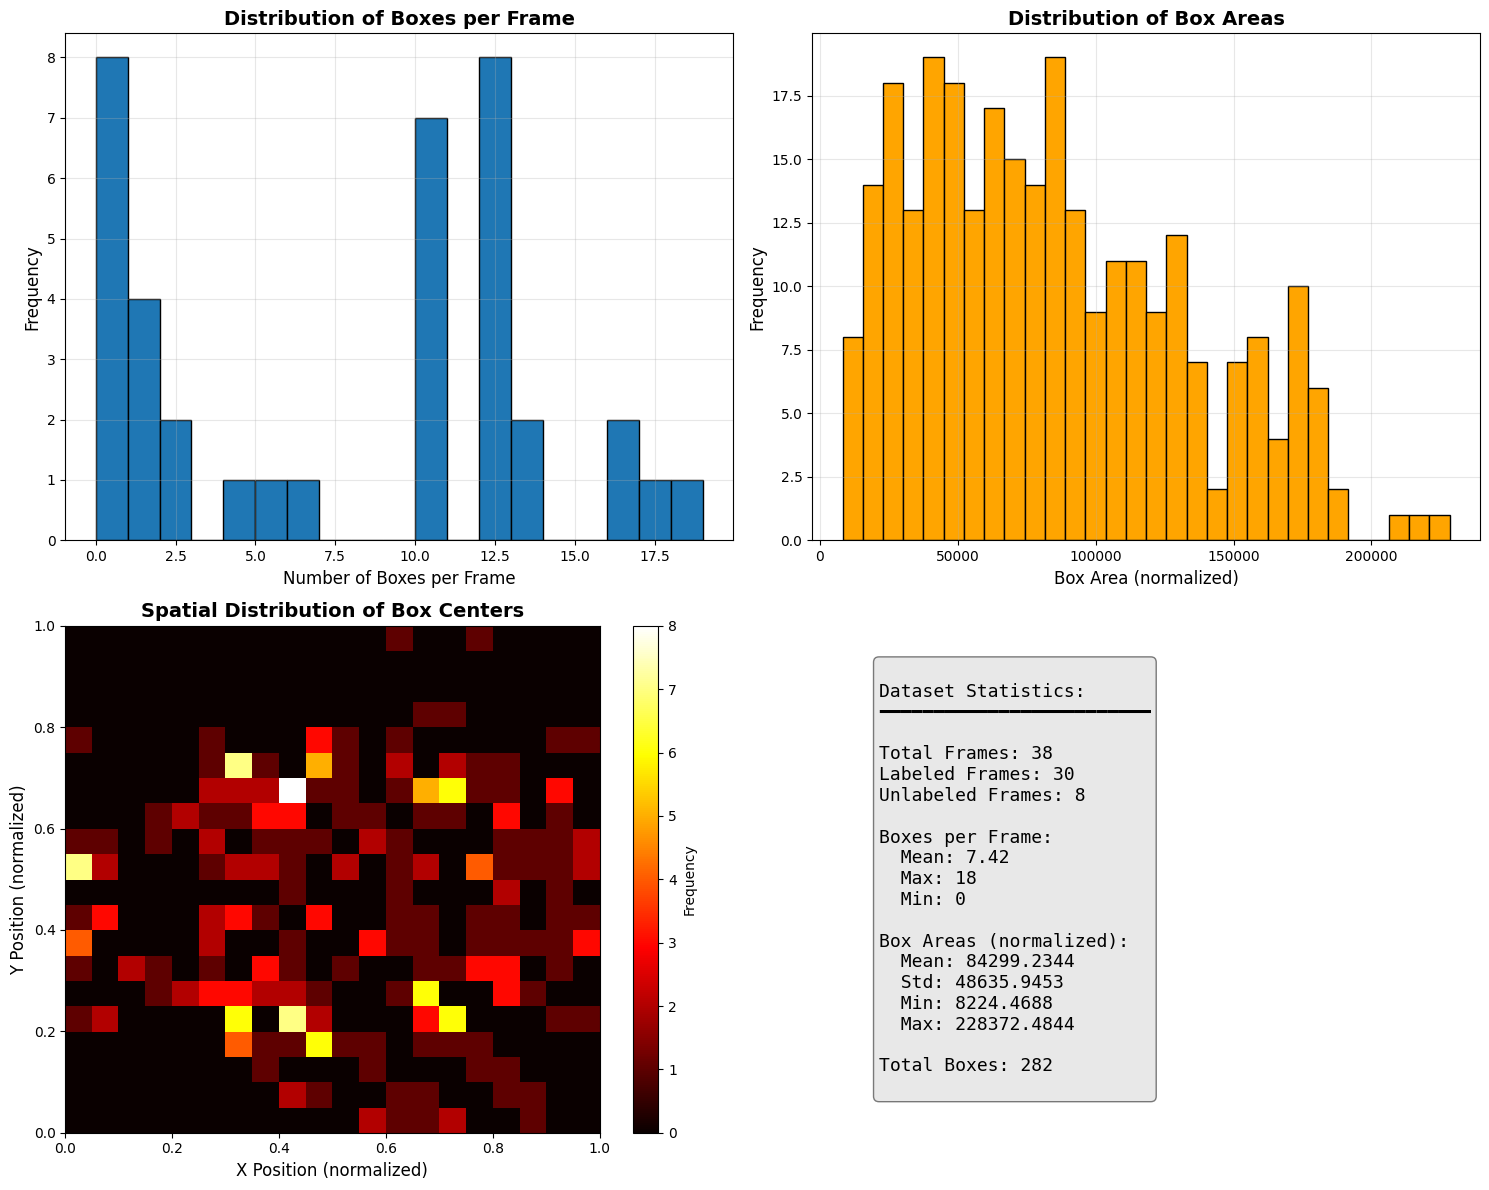


Dataset Analysis Complete


In [15]:
# Collect statistics
box_counts = []
box_areas = []
box_positions_x = []
box_positions_y = []

for idx in range(len(dataset)):
    _, target = dataset[idx]
    if target['boxes'] is not None and len(target['boxes']) > 0:
        box_counts.append(len(target['boxes']))
        for box in target['boxes']:
            x, y, w, h = box.numpy()
            box_areas.append(w * h)
            box_positions_x.append(x + w/2)  # center x
            box_positions_y.append(y + h/2)  # center y
    else:
        box_counts.append(0)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Box count distribution
axes[0, 0].hist(box_counts, bins=range(max(box_counts)+2), edgecolor='black')
axes[0, 0].set_xlabel('Number of Boxes per Frame', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Boxes per Frame', fontsize=14, weight='bold')
axes[0, 0].grid(alpha=0.3)

# Box area distribution
if box_areas:
    axes[0, 1].hist(box_areas, bins=30, edgecolor='black', color='orange')
    axes[0, 1].set_xlabel('Box Area (normalized)', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].set_title('Distribution of Box Areas', fontsize=14, weight='bold')
    axes[0, 1].grid(alpha=0.3)

# Box position heatmap
if box_positions_x and box_positions_y:
    h, xedges, yedges = np.histogram2d(box_positions_x, box_positions_y, bins=20)
    im = axes[1, 0].imshow(h.T, origin='lower', cmap='hot', aspect='auto',
                           extent=[0, 1, 0, 1])
    axes[1, 0].set_xlabel('X Position (normalized)', fontsize=12)
    axes[1, 0].set_ylabel('Y Position (normalized)', fontsize=12)
    axes[1, 0].set_title('Spatial Distribution of Box Centers', fontsize=14, weight='bold')
    plt.colorbar(im, ax=axes[1, 0], label='Frequency')

# Summary statistics
axes[1, 1].axis('off')
summary_text = f"""
Dataset Statistics:
━━━━━━━━━━━━━━━━━━━━━━━━━

Total Frames: {len(dataset)}
Labeled Frames: {len(labeled_indices)}
Unlabeled Frames: {len(unlabeled_indices)}

Boxes per Frame:
  Mean: {np.mean(box_counts):.2f}
  Max: {max(box_counts)}
  Min: {min(box_counts)}

Box Areas (normalized):
  Mean: {np.mean(box_areas):.4f}
  Std: {np.std(box_areas):.4f}
  Min: {min(box_areas):.4f}
  Max: {max(box_areas):.4f}

Total Boxes: {len(box_areas)}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=13, verticalalignment='center',
               family='monospace', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Dataset Analysis Complete")
print("="*50)